In [2]:
pip install kagglehub

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anthonytherrien/dog-vs-cat")

print("Path to dataset files:", path)

100%|██████████| 360M/360M [00:01<00:00, 196MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/anthonytherrien/dog-vs-cat/versions/3


In [6]:
!unzip /content/archive.zip

Archive:  /content/archive.zip
  inflating: animals/cat/00000-4122619873.png  
  inflating: animals/cat/00001-4122619874.png  
  inflating: animals/cat/00002-4122619875.png  
  inflating: animals/cat/00003-4122619876.png  
  inflating: animals/cat/00004-4122619877.png  
  inflating: animals/cat/00005-4122619878.png  
  inflating: animals/cat/00006-4122619879.png  
  inflating: animals/cat/00007-4122619880.png  
  inflating: animals/cat/00008-4122619881.png  
  inflating: animals/cat/00009-4122619882.png  
  inflating: animals/cat/00010-4122619883.png  
  inflating: animals/cat/00011-4122619884.png  
  inflating: animals/cat/00012-4122619885.png  
  inflating: animals/cat/00013-4122619886.png  
  inflating: animals/cat/00014-4122619887.png  
  inflating: animals/cat/00015-4122619888.png  
  inflating: animals/cat/00016-4122619889.png  
  inflating: animals/cat/00017-4122619890.png  
  inflating: animals/cat/00018-4122619891.png  
  inflating: animals/cat/00019-4122619892.png  
  inflati

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Preprocessing
Image Augmentation

This helps prevent overfitting.

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Load images:

In [11]:
import os

cat_count = len(os.listdir('/content/animals/cat'))
dog_count = len(os.listdir('/content/animals/dog'))

print("Cats:", cat_count)
print("Dogs:", dog_count)

Cats: 500
Dogs: 500


In [12]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/animals",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(150, 150),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/animals",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(150, 150),
    batch_size=32
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [13]:
print(train_ds.class_names)

['cat', 'dog']


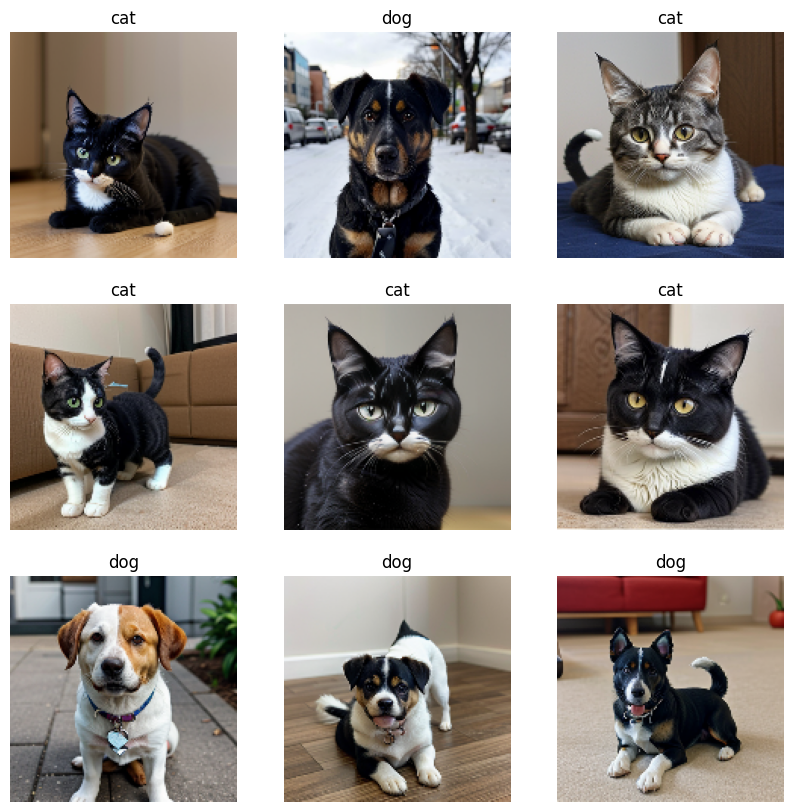

In [14]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

# Build CNN Model

**What each layer does**

| Layer      | Purpose               |
| ---------- | --------------------- |
| Conv2D     | Extract features      |
| MaxPooling | Reduce image size     |
| Flatten    | Convert 2D to 1D      |
| Dense      | Learn patterns        |
| Dropout    | Reduce overfitting    |
| Sigmoid    | Binary classification |


In [16]:
model = Sequential([

    Conv2D(32,(3,3),activation='relu',
           input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile Model

In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
%whos

Variable             Type                  Data/Info
----------------------------------------------------
Conv2D               type                  <class 'keras.src.layers.<...>olutional.conv2d.Conv2D'>
Dense                type                  <class 'keras.src.layers.core.dense.Dense'>
Dropout              type                  <class 'keras.src.layers.<...>ization.dropout.Dropout'>
Flatten              type                  <class 'keras.src.layers.<...>shaping.flatten.Flatten'>
ImageDataGenerator   type                  <class 'keras.src.legacy.<...>mage.ImageDataGenerator'>
MaxPooling2D         type                  <class 'keras.src.layers.<...>_pooling2d.MaxPooling2D'>
Sequential           type                  <class 'keras.src.models.sequential.Sequential'>
ax                   Axes                  Axes(0.672794,0.11;0.226471x0.226471)
cat_count            int                   500
dog_count            int                   500
i                    int                   8


In [24]:
train_ds
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [26]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.8650 - loss: 0.6571
Validation Loss: 0.6570600867271423
Validation Accuracy: 0.8650000095367432


# Train Model

In [21]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 311ms/step - accuracy: 0.6725 - loss: 30.2174 - val_accuracy: 0.8000 - val_loss: 0.4500
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 247ms/step - accuracy: 0.8675 - loss: 0.3183 - val_accuracy: 0.8750 - val_loss: 0.3006
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 284ms/step - accuracy: 0.9513 - loss: 0.1395 - val_accuracy: 0.8600 - val_loss: 0.3354
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 232ms/step - accuracy: 0.8900 - loss: 0.3068 - val_accuracy: 0.7750 - val_loss: 0.4968
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.9450 - loss: 0.1504 - val_accuracy: 0.8250 - val_loss: 0.5008
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step - accuracy: 0.9613 - loss: 0.0977 - val_accuracy: 0.8100 - val_loss: 0.5312
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 284ms/step - accuracy: 0.9800 - loss: 0.0651 - val_accuracy: 0.8200 - val_loss: 0.7421
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 299ms/step - accuracy: 0.9975 - loss: 0.0182 - val_accurac

# Evaluate Model

In [27]:
for images, labels in val_ds.take(1):
    predictions = model.predict(images)

    print("Actual Labels:")
    print(labels.numpy())

    print("Predicted Labels:")
    print((predictions > 0.5).astype(int).flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
Actual Labels:
[1 0 1 1 1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0]
Predicted Labels:
[1 0 1 1 1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0]


# Predict New Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


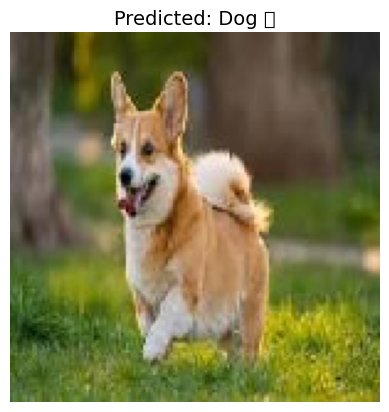

Prediction: Dog 🐶


In [34]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

# Load image
img_path = "/content/download.jpeg"

img = image.load_img(
    img_path,
    target_size=(150,150)
)

# Display image
plt.imshow(img)
plt.axis("off")

# Preprocess image
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    label = "Dog 🐶"
else:
    label = "Cat 🐱"

# Show prediction as title
plt.title(f"Predicted: {label}", fontsize=14)
plt.show()

print("Prediction:", label)

# Visualize Accuracy and Loss

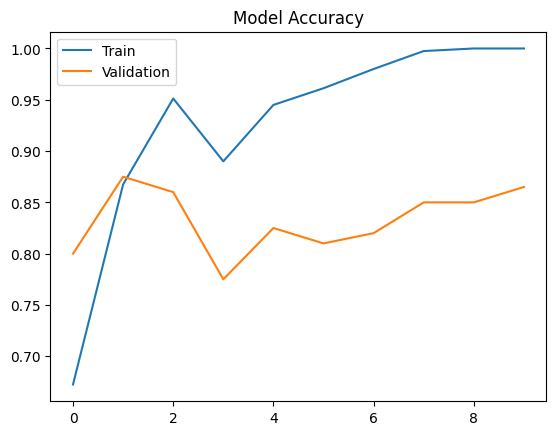

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train','Validation'])
plt.show()

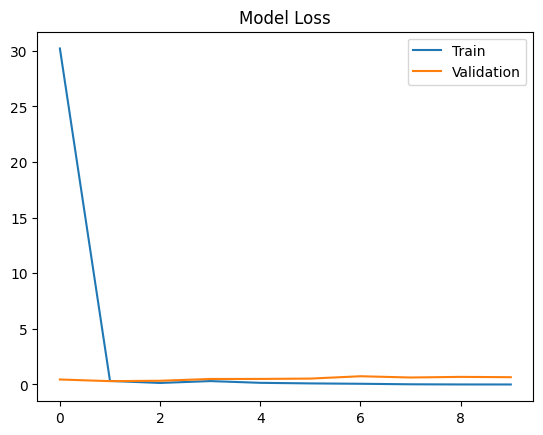

In [31]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(['Train','Validation'])
plt.show()

# CNN Flow Diagram

f(x)→Conv2D→MaxPool→Conv2D→MaxPool→Flatten→Dense→Output


Image → Convolution → Pooling → Convolution → Pooling → Flatten → Dense → Cat/Dog

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


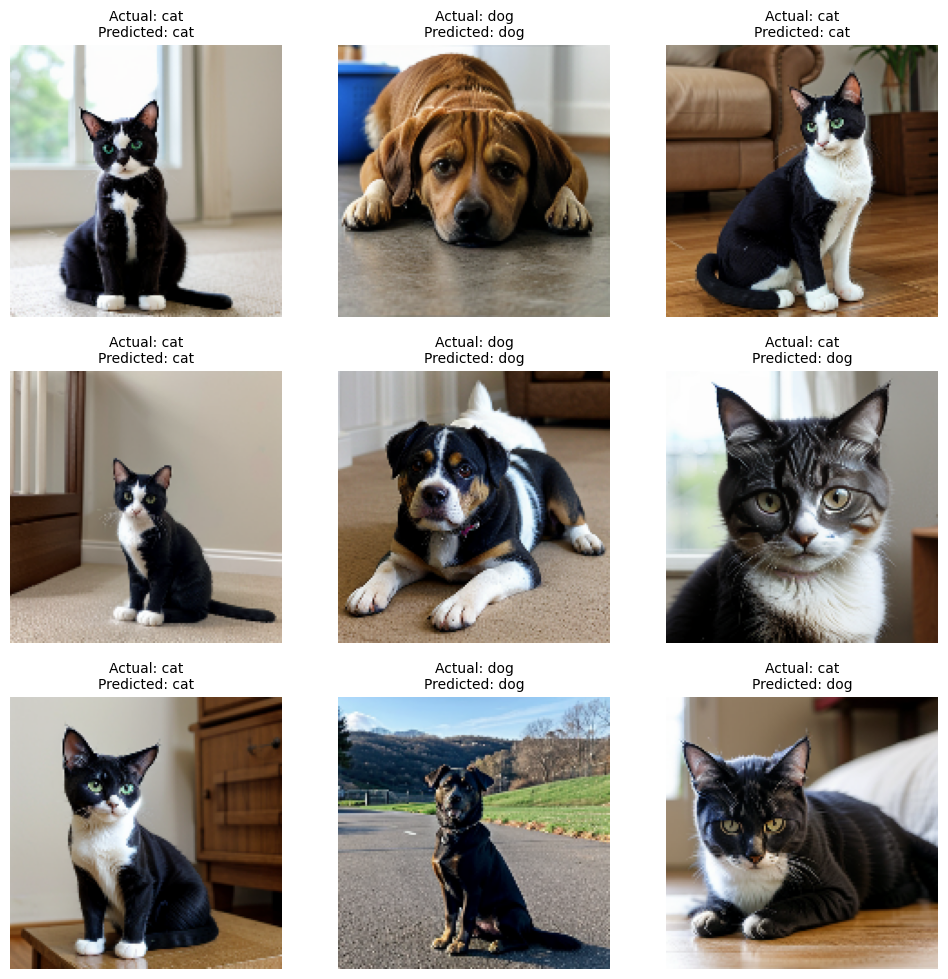

In [32]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['cat', 'dog']

for images, labels in val_ds.take(1):

    predictions = model.predict(images)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    plt.figure(figsize=(12, 12))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[labels[i].numpy()]
        predicted = class_names[predicted_labels[i]]

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}",
            fontsize=10
        )

        plt.axis("off")

    plt.show()